# Importing Required Libraries

In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data loading and cleaning

In [157]:
df=pd.read_csv(r"/home/hemanth/Desktop/AFTER BTECH/innomatics/inno_hack/EV Charging Behavior Dataset.csv")

In [158]:
df.head()

,User_ID,Age,City_Tier,EV_Type,Battery_Capacity_kWh,Charging_Sessions_Per_Month,Avg_Charge_Cost,Distance_Travelled_Per_Month,Income_Level,Loan_Taken,Missed_Payments_Last_6M,Tenure_Months,Charging_Location_Type,App_Usage_Score,Charger_Working_Status,Charging_Time_Minutes,High_Default_Risk,Charging_Efficiency_Index
0,1,59,Tier3,5KW,40.7,19,325.10,1702,Low,0,2,1,Public,1,Working,58.5,0,100.00
1,2,49,Tier5,5KW,31.7,9,439.97,2377,High,0,0,1,Highway,7,Working,47.0,0,96.36
2,3,35,Tier5,5KW,36.8,24,309.80,1905,Low,0,5,6,Highway,4,Working,53.5,1,100.00
3,4,63,Tier5,2KW,38.5,32,353.90,2074,Medium,0,1,31,Highway,1,Not Working,112.0,1,57.96
4,5,28,Tier1,5KW,33.2,8,597.43,1212,Medium,0,2,24,Private,6,Working,58.0,0,84.56


In [159]:
df.tail()

,User_ID,Age,City_Tier,EV_Type,Battery_Capacity_kWh,Charging_Sessions_Per_Month,Avg_Charge_Cost,Distance_Travelled_Per_Month,Income_Level,Loan_Taken,Missed_Payments_Last_6M,Tenure_Months,Charging_Location_Type,App_Usage_Score,Charger_Working_Status,Charging_Time_Minutes,High_Default_Risk,Charging_Efficiency_Index
18941,18942,54,Tier5,2KW,38.0,23,420.80,938,High,0,0,16,Highway,8,Working,58.0,0,100.0
18942,18943,47,Tier3,5KW,28.6,29,555.51,1289,High,1,1,28,Highway,1,Working,39.8,1,100.0
18943,18944,59,Tier2,5KW,28.6,17,500.97,577,Medium,0,5,15,Private,3,Working,34.3,0,100.0
18944,18945,64,Tier2,4KW,42.3,30,417.63,2255,Low,0,1,18,Highway,2,Working,65.3,1,100.0
18945,18946,58,Tier1,4KW,47.6,34,358.95,2332,High,1,0,36,Private,8,Working,75.3,0,100.0


In [160]:
df.drop(columns="User_ID",inplace=True)

In [161]:
df.duplicated().sum()

np.int64(0)

In [162]:
df['EV_Type'].value_counts()

EV_Type
2KW    7654
5KW    5600
4KW    3832
3KW    1860
Name: count, dtype: int64

In [163]:
df['EV_Type_In_KW']=df['EV_Type'].apply(lambda x:int(x[:1:]))

In [164]:
df.drop(columns='EV_Type',inplace=True)

In [165]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18946 entries, 0 to 18945
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age                           18946 non-null  int64  
 1   City_Tier                     18946 non-null  object 
 2   Battery_Capacity_kWh          18946 non-null  float64
 3   Charging_Sessions_Per_Month   18946 non-null  int64  
 4   Avg_Charge_Cost               18946 non-null  float64
 5   Distance_Travelled_Per_Month  18946 non-null  int64  
 6   Income_Level                  18946 non-null  object 
 7   Loan_Taken                    18946 non-null  int64  
 8   Missed_Payments_Last_6M       18946 non-null  int64  
 9   Tenure_Months                 18946 non-null  int64  
 10  Charging_Location_Type        18946 non-null  object 
 11  App_Usage_Score               18946 non-null  int64  
 12  Charger_Working_Status        18946 non-null  object 
 13  C

In [166]:
df.isnull().sum()

Age                             0
City_Tier                       0
Battery_Capacity_kWh            0
Charging_Sessions_Per_Month     0
Avg_Charge_Cost                 0
Distance_Travelled_Per_Month    0
Income_Level                    0
Loan_Taken                      0
Missed_Payments_Last_6M         0
Tenure_Months                   0
Charging_Location_Type          0
App_Usage_Score                 0
Charger_Working_Status          0
Charging_Time_Minutes           0
High_Default_Risk               0
Charging_Efficiency_Index       0
EV_Type_In_KW                   0
dtype: int64

# Univariate Analysis

In [167]:
for i in df.select_dtypes(include='object'):
    print(df[i].value_counts())

City_Tier
Tier5    5716
Tier3    4716
Tier1    3706
Tier2    2841
Tier4    1967
Name: count, dtype: int64
Income_Level
Medium    8586
Low       6614
High      3746
Name: count, dtype: int64
Charging_Location_Type
Highway    6450
Public     6303
Private    6193
Name: count, dtype: int64
Charger_Working_Status
Working        16094
Not Working     2852
Name: count, dtype: int64


In [183]:
df['City_Tier'].value_counts()

City_Tier
Tier5    5716
Tier3    4716
Tier1    3706
Tier2    2841
Tier4    1967
Name: count, dtype: int64

In [177]:
indexes=df['City_Tier'].value_counts().index
df_values=df['City_Tier'].value_counts().values

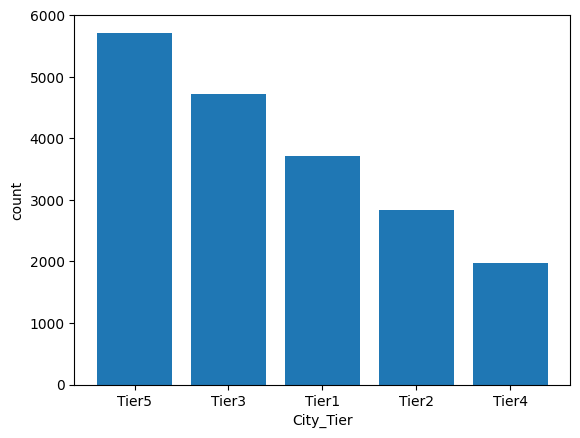

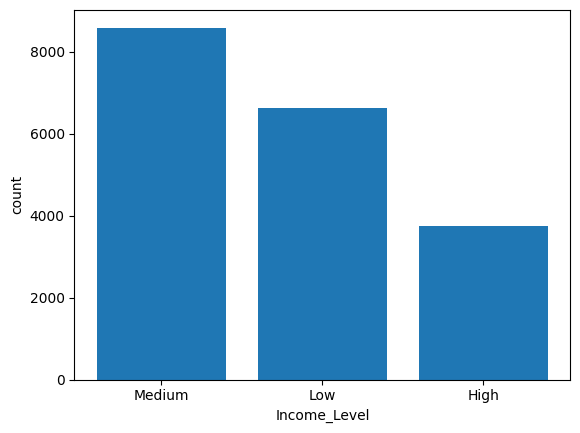

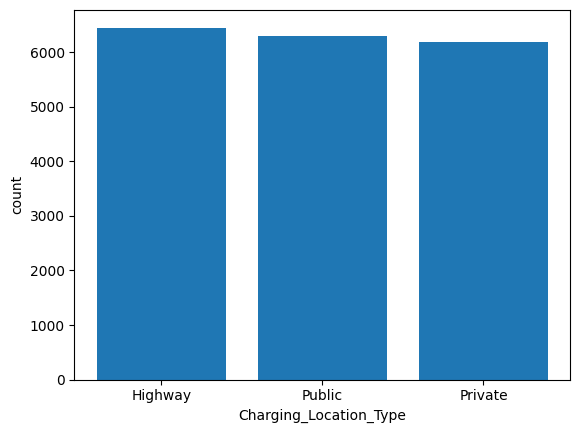

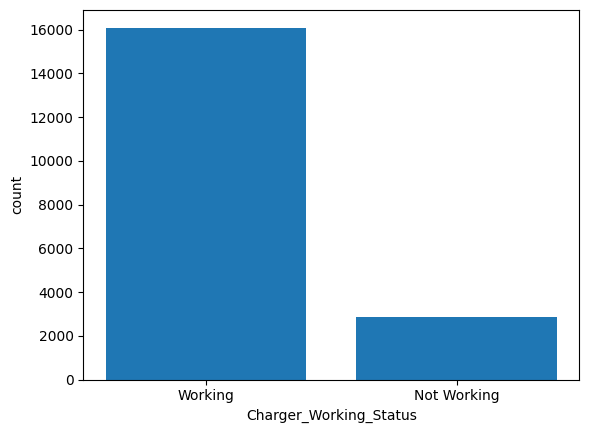

In [185]:
for i in df.select_dtypes(include='object'):
    indexes=df[i].value_counts().index
    df_values=df[i].value_counts().values
    plt.bar(indexes,df_values)
    plt.xlabel(i)
    plt.ylabel('count')
    plt.show()

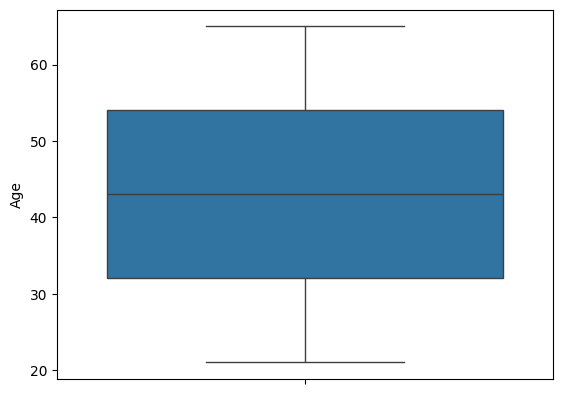

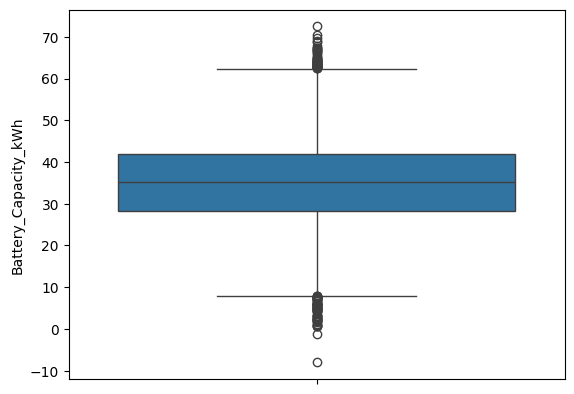

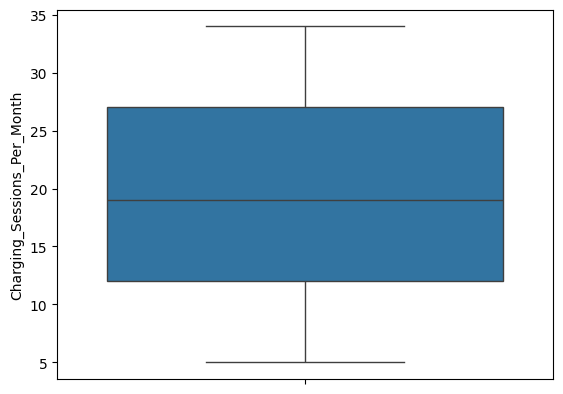

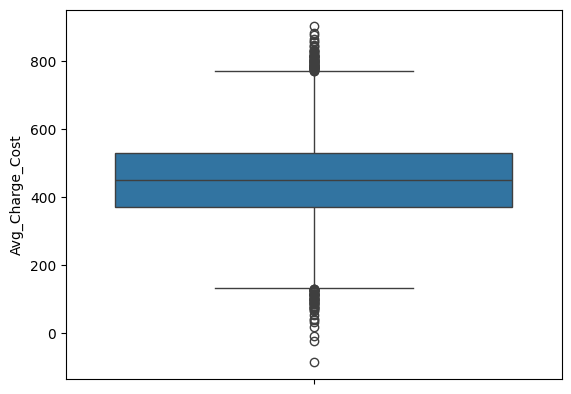

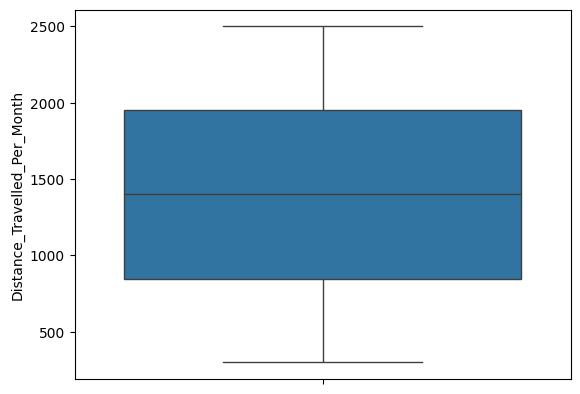

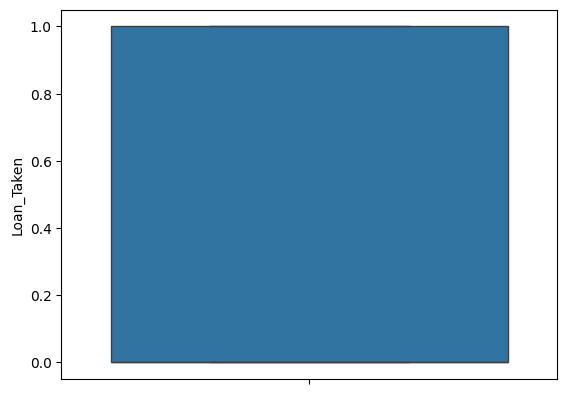

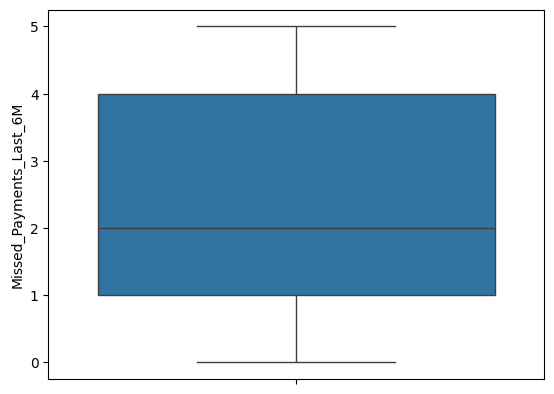

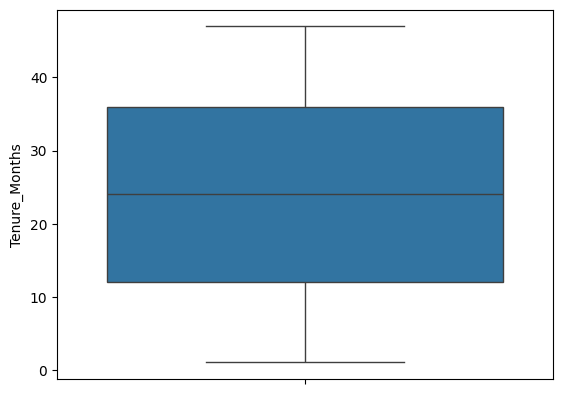

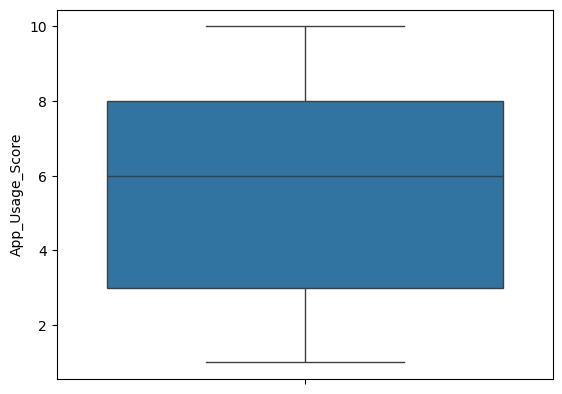

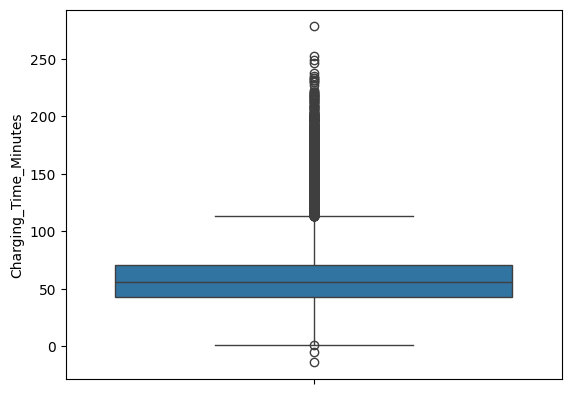

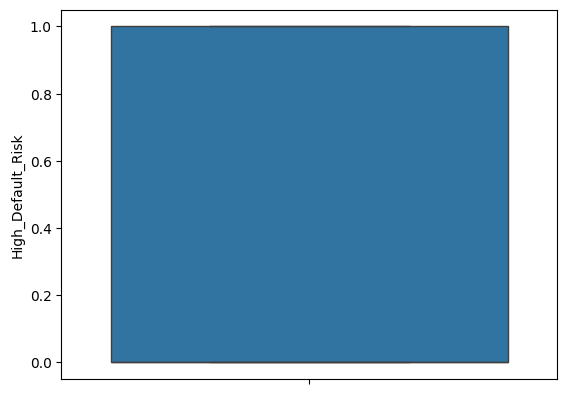

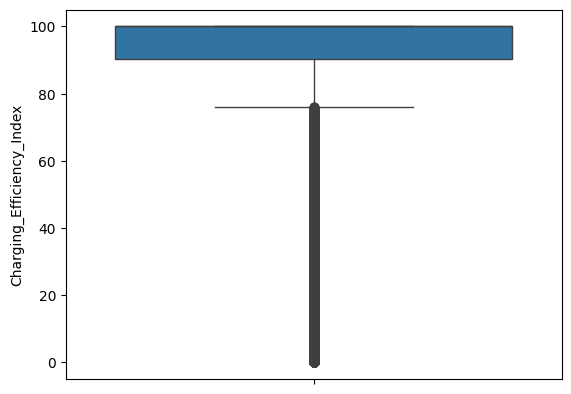

In [27]:
for i in df.select_dtypes(exclude='object'):
    sns.boxplot(df[i])
    plt.show()

# Data preprocessing

In [58]:
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

In [65]:
trans=ColumnTransformer([("scaler",RobustScaler(),[0,2,4,5,15]),('encoder',OrdinalEncoder(),[1,6,10,12])],remainder='passthrough')

In [66]:
trans.fit_transform(df)

array([[ 7.27272727e-01,  4.11764706e-01, -7.77027343e-01, ...,
         5.85000000e+01,  0.00000000e+00,  5.00000000e+00],
       [ 2.72727273e-01, -2.50000000e-01, -6.03328602e-02, ...,
         4.70000000e+01,  0.00000000e+00,  5.00000000e+00],
       [-3.63636364e-01,  1.25000000e-01, -8.72486781e-01, ...,
         5.35000000e+01,  1.00000000e+00,  5.00000000e+00],
       ...,
       [ 7.27272727e-01, -4.77941176e-01,  3.20257054e-01, ...,
         3.43000000e+01,  0.00000000e+00,  5.00000000e+00],
       [ 9.54545455e-01,  5.29411765e-01, -1.99716117e-01, ...,
         6.53000000e+01,  1.00000000e+00,  4.00000000e+00],
       [ 6.81818182e-01,  9.19117647e-01, -5.65831137e-01, ...,
         7.53000000e+01,  0.00000000e+00,  4.00000000e+00]],
      shape=(18946, 17))

In [67]:
trans.get_feature_names_out()

array(['scaler__Age', 'scaler__Battery_Capacity_kWh',
       'scaler__Avg_Charge_Cost', 'scaler__Distance_Travelled_Per_Month',
       'scaler__Charging_Efficiency_Index', 'encoder__City_Tier',
       'encoder__Income_Level', 'encoder__Charging_Location_Type',
       'encoder__Charger_Working_Status',
       'remainder__Charging_Sessions_Per_Month', 'remainder__Loan_Taken',
       'remainder__Missed_Payments_Last_6M', 'remainder__Tenure_Months',
       'remainder__App_Usage_Score', 'remainder__Charging_Time_Minutes',
       'remainder__High_Default_Risk', 'remainder__EV_Type_In_KW'],
      dtype=object)

# featuture Selection

In [69]:
feat_eng=pd.DataFrame(data=trans.fit_transform(df),columns=trans.get_feature_names_out())

<Axes: >

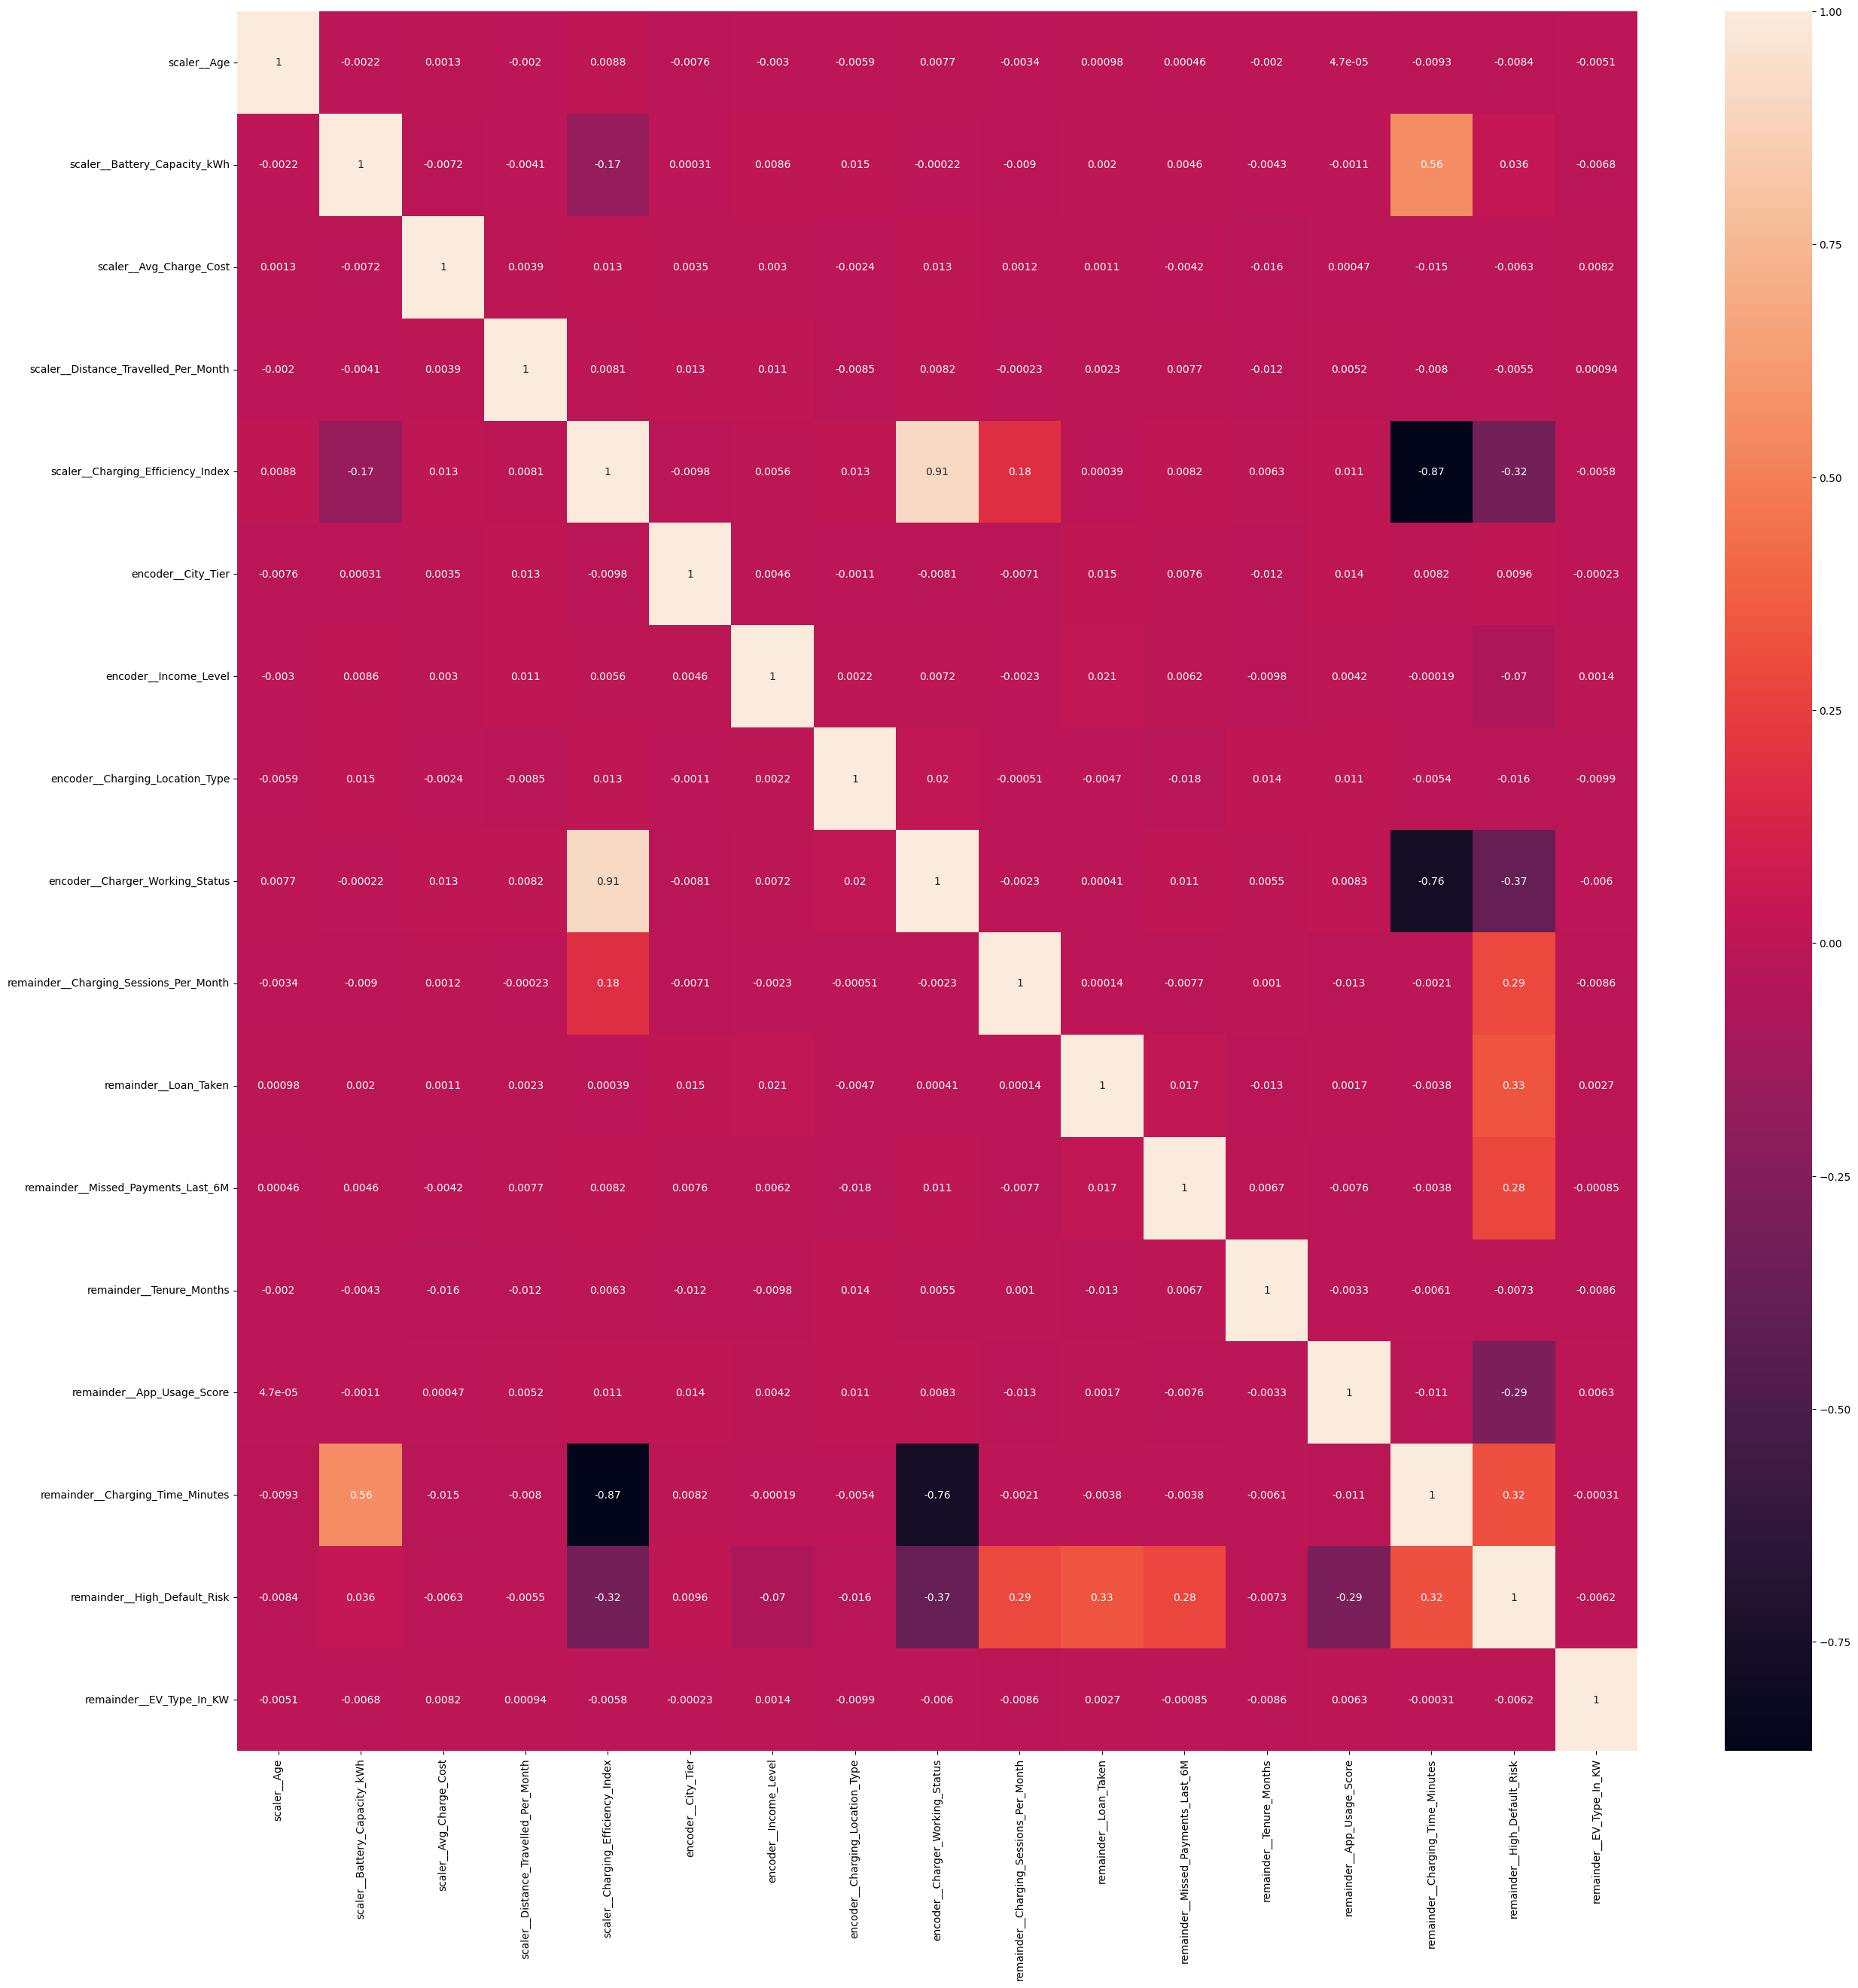

In [79]:
plt.figure(figsize=(30,30))
sns.heatmap(feat_eng.corr(),annot=True)

In [81]:
X=df.drop(columns='High_Default_Risk')
y=df['High_Default_Risk']

In [92]:
y=y.apply(lambda x:"High Risk" if x ==1 else 'Low Risk')

# Modeling

In [93]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=22)

In [94]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((15156, 16), (3790, 16), (15156,), (3790,))

In [95]:
trans=ColumnTransformer([("scaler",RobustScaler(),[0,2,4,5,14]),('encoder',OrdinalEncoder(),[1,6,10,12])],remainder='passthrough')

In [96]:
X_train_trans=trans.fit_transform(X_train)
X_test_trans=trans.transform(X_test)

In [97]:
X_train_trans.shape

(15156, 16)

In [101]:
from sklearn.metrics import classification_report

In [103]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()
knn.fit(X_train_trans,y_train)
y_pred=knn.predict(X_test_trans)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

   High Risk       0.72      0.75      0.73      1638
    Low Risk       0.80      0.78      0.79      2152

    accuracy                           0.77      3790
   macro avg       0.76      0.76      0.76      3790
weighted avg       0.77      0.77      0.77      3790



In [110]:
from sklearn.naive_bayes import BernoulliNB
nb=BernoulliNB()
nb.fit(X_train_trans,y_train)
y_pred=nb.predict(X_test_trans)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

   High Risk       0.64      0.74      0.69      1476
    Low Risk       0.82      0.73      0.77      2314

    accuracy                           0.74      3790
   macro avg       0.73      0.74      0.73      3790
weighted avg       0.75      0.74      0.74      3790



In [111]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt.fit(X_train_trans,y_train)
y_pred=dt.predict(X_test_trans)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

   High Risk       1.00      1.00      1.00      1718
    Low Risk       1.00      1.00      1.00      2072

    accuracy                           1.00      3790
   macro avg       1.00      1.00      1.00      3790
weighted avg       1.00      1.00      1.00      3790



In [132]:
dt.get_depth()

10

In [133]:
dt.get_n_leaves()

np.int64(85)

In [136]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(max_depth=8)
dt.fit(X_train_trans,y_train)
y_pred=dt.predict(X_test_trans)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

   High Risk       1.00      1.00      1.00      1714
    Low Risk       1.00      1.00      1.00      2076

    accuracy                           1.00      3790
   macro avg       1.00      1.00      1.00      3790
weighted avg       1.00      1.00      1.00      3790



In [119]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(X_train_trans,y_train)
y_pred=lr.predict(X_test_trans)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

   High Risk       0.79      0.82      0.81      1650
    Low Risk       0.86      0.83      0.85      2140

    accuracy                           0.83      3790
   macro avg       0.82      0.83      0.83      3790
weighted avg       0.83      0.83      0.83      3790



/home/hemanth/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [122]:
from sklearn.svm import SVC
support_V=SVC()
support_V.fit(X_train_trans,y_train)
y_pred=support_V.predict(X_test_trans)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

   High Risk       0.75      0.82      0.78      1573
    Low Risk       0.86      0.80      0.83      2217

    accuracy                           0.81      3790
   macro avg       0.80      0.81      0.81      3790
weighted avg       0.81      0.81      0.81      3790



In [151]:
from sklearn.svm import SVC
support_V_lr=SVC(kernel='linear')
support_V_lr.fit(X_train_trans,y_train)
y_pred=support_V_lr.predict(X_test_trans)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

   High Risk       0.78      0.84      0.81      1599
    Low Risk       0.88      0.83      0.85      2191

    accuracy                           0.83      3790
   macro avg       0.83      0.84      0.83      3790
weighted avg       0.84      0.83      0.84      3790



In [125]:
from sklearn.svm import SVC
support_V=SVC(kernel='poly')
support_V.fit(X_train_trans,y_train)
y_pred=support_V.predict(X_test_trans)
print(classification_report(y_pred,y_test)) 

              precision    recall  f1-score   support

   High Risk       0.65      0.85      0.74      1323
    Low Risk       0.90      0.76      0.83      2467

    accuracy                           0.79      3790
   macro avg       0.78      0.80      0.78      3790
weighted avg       0.82      0.79      0.80      3790



In [148]:
from sklearn.svm import SVC
support_V=SVC(kernel='sigmoid')
support_V.fit(X_train_trans,y_train)
y_pred=support_V.predict(X_test_trans)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

   High Risk       0.36      0.37      0.37      1687
    Low Risk       0.49      0.48      0.48      2103

    accuracy                           0.43      3790
   macro avg       0.42      0.42      0.42      3790
weighted avg       0.43      0.43      0.43      3790



In [139]:
from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier,HistGradientBoostingClassifier,RandomForestClassifier,StackingClassifier

In [130]:
pip install xgboost

  Using cached xgboost-3.2.0-py3-none-manylinux_2_28_x86_64.whl.metadata (2.1 kB)
  Using cached nvidia_nccl_cu12-2.29.7-py3-none-manylinux_2_18_x86_64.whl.metadata (2.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/131.7 MB ? eta -:--:--0m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/131.7 MB ? eta -:--:--^C
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/131.7 MB ? eta -:--:--
ERROR: Operation cancelled by user
Note: you may need to restart the kernel to use updated packages.


In [152]:
adaboost=AdaBoostClassifier(estimator=support_V_lr)
adaboost.fit(X_train_trans,y_train)
y_pred=adaboost.predict(X_test_trans)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

   High Risk       0.71      0.79      0.75      1533
    Low Risk       0.85      0.78      0.81      2257

    accuracy                           0.79      3790
   macro avg       0.78      0.79      0.78      3790
weighted avg       0.79      0.79      0.79      3790



In [186]:
#from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(max_depth=8)
model.fit(X_train_trans,y_train)
y_pred=model.predict(X_test_trans)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

   High Risk       1.00      1.00      1.00      1715
    Low Risk       1.00      1.00      1.00      2075

    accuracy                           1.00      3790
   macro avg       1.00      1.00      1.00      3790
weighted avg       1.00      1.00      1.00      3790



In [191]:
import pickle as pkl
with open ("model.pkl","wb") as f:
    pkl.dump(model,f)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

nb=BernoulliNB()
nb.fit(X_train_trans,y_train)
y_pred=nb.predict(X_test_trans)
print(classification_report(y_pred,y_test))